# 📊 Database Insights & Exploratory Data Analysis
Project: Multi-Sheet Database Analysis  
File: clean_project.xlsx  

---
### 📌 Overview
This report aims to load, explore, and analyze the structured relational database sheets in clean_project.xlsx. It delivers both Quantitative Insights (statistical aggregations) and Visual Insights (data visualizations) to drive data-informed decision-making.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style setup
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# File Path Configuration
file_path = "clean_project.xlsx"

In [3]:
excel_file = pd.ExcelFile(file_path)

print(" Sheet Names Found in Database:")
for i, sheet in enumerate(excel_file.sheet_names, 1):
    print(f"  {i}. {sheet}")

sheets_dict = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in excel_file.sheet_names}

print("\nDataset Overview (Dimensions per Sheet):")
for sheet_name, df in sheets_dict.items():
    print(f"  • {sheet_name}: {df.shape[0]:,} Rows × {df.shape[1]} Columns")

 Sheet Names Found in Database:
  1. online_shopping_db_branches
  2. online_shopping_db_categories
  3. Clean_online_shopping_db_custom
  4. online_shopping_db_employees
  5. online_shopping_db_order_activi
  6. online_shopping_db_order_items
  7. online_shopping_db_orders
  8. Clean_online_shopping_db_produc
  9. Sheet9
  10. Sheet8
  11. Sheet7
  12. Sheet6
  13. Sheet2
  14. online_shopping_db_deliveries
  15. Sheet5
  16. Sheet4
  17. Sheet3
  18. Sheet1

Dataset Overview (Dimensions per Sheet):
  • online_shopping_db_branches: 24 Rows × 4 Columns
  • online_shopping_db_categories: 20 Rows × 2 Columns
  • Clean_online_shopping_db_custom: 3,000 Rows × 7 Columns
  • online_shopping_db_employees: 3,000 Rows × 8 Columns
  • online_shopping_db_order_activi: 3,000 Rows × 6 Columns
  • online_shopping_db_order_items: 3,000 Rows × 5 Columns
  • online_shopping_db_orders: 3,000 Rows × 8 Columns
  • Clean_online_shopping_db_produc: 3,000 Rows × 6 Columns
  • Sheet9: 3,000 Rows × 6 Columns
 

In [4]:
excel_file = pd.ExcelFile(file_path)

sheets_dict = {sheet: pd.read_excel(file_path, sheet_name=sheet) for sheet in excel_file.sheet_names}

print(" DATABASE STRUCTURE OVERVIEW:\n" + "="*50)

for sheet_name, df in sheets_dict.items():
    print(f"\n Sheet: [{sheet_name}]")
    print(f"   • Dimensions: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"   • Columns: {list(df.columns)}")

 DATABASE STRUCTURE OVERVIEW:

 Sheet: [online_shopping_db_branches]
   • Dimensions: 24 rows × 4 columns
   • Columns: ['Branch_ID', 'Branch_Name', 'Location', 'Phone_Number']

 Sheet: [online_shopping_db_categories]
   • Dimensions: 20 rows × 2 columns
   • Columns: ['Category_ID', 'Category_Name']

 Sheet: [Clean_online_shopping_db_custom]
   • Dimensions: 3,000 rows × 7 columns
   • Columns: ['Customer_ID', 'Customer_Name', 'Email', 'Phone', 'Gender', 'City', 'Registration_Date']

 Sheet: [online_shopping_db_employees]
   • Dimensions: 3,000 rows × 8 columns
   • Columns: ['Employee_ID', 'Employee_Name', 'Job_Title', 'Salary', 'Phone_Number', 'Email', 'Gender', 'BranchID']

 Sheet: [online_shopping_db_order_activi]
   • Dimensions: 3,000 rows × 6 columns
   • Columns: ['Activity_ID', 'Activity_Type', 'Activity_Date', 'Status', 'OrderId', 'EmployeeID']

 Sheet: [online_shopping_db_order_items]
   • Dimensions: 3,000 rows × 5 columns
   • Columns: ['OrderID', 'ProductID', 'Quantity',

In [ ]:
df_customers = sheets_dict['Clean_online_shopping_db_custom']

total_customers = len(df_customers)
gender_counts = df_customers['Gender'].value_counts()
top_cities = df_customers['City'].value_counts().head(3)

print(f"Total Registered Customers: {total_customers:,}\n")
print("Gender Distribution:")
print(gender_counts.to_string())
print("\nTop 3 Cities:")
print(top_cities.to_string())

Total Registered Customers: 3,000

Gender Distribution:
Gender
Female    1506
Male      1494

Top 3 Cities:
City
Cairo         935
Alexandria    590
Sohag         576


###  Key Insights: Customer Demographics & Geographic Distribution

* Total Active Customer Base: The database contains 3,000 registered customers, providing a solid sample size for behavioral and demographic analysis.
* Balanced Gender Ratio: The customer base exhibits a nearly equal gender split, with 50.2% Female (1,506 users) and 49.8% Male (1,494 users), indicating broad market reach across both demographic segments.
* Geographic Concentration:
  * Cairo represents the primary market hub with 935 customers (~31.2% of total customers).
  * Alexandria ranks second with 590 customers (~19.7%).
  * Sohag holds a strong third position with 576 customers (~19.2%).
* Strategic Takeaway: Nearly 70% of the customer base is concentrated in these top 3 cities, highlighting key regional targets for logistical optimization, localized marketing campaigns, and delivery branch expansion.

In [6]:
df_employees = sheets_dict['online_shopping_db_employees']

total_payroll = df_employees['Salary'].sum()
avg_salary = df_employees['Salary'].mean()
salary_by_title = df_employees.groupby('Job_Title')['Salary'].mean().sort_values(ascending=False)

print(f"Total Monthly Payroll: ${total_payroll:,.2f}")
print(f"Average Employee Salary: ${avg_salary:,.2f}\n")
print("Average Salary by Job Title:")
print(salary_by_title.to_string())

Total Monthly Payroll: $21,831,660.00
Average Employee Salary: $7,277.22

Average Salary by Job Title:
Job_Title
Accountant    7381.462437
Hr            7313.243243
Manager       7279.439145
Support       7261.433058
Sales         7139.656530


###  Key Insights: Employee Payroll Analysis

* Total Monthly Payroll: The company spends $21,831,660.00 monthly on employee salaries.
* Average Salary Baseline: The average monthly salary across all roles is $7,277.22.
* Role Breakdown: 
  * Accountant: $7,381.46 | HR: $7,313.24 | Manager: $7,279.44
  * Support: $7,261.43 | Sales: $7,139.66
* Key Takeaway: Salaries are highly consistent across departments (ranging between ~$7,140 and ~$7,381), indicating a balanced pay structure with minimal gap between managerial and operational roles.

In [7]:
df_items = sheets_dict['online_shopping_db_order_items']

df_items['Total_Price'] = df_items['Quantity'] * df_items['Selling_Price']
total_revenue = df_items['Total_Price'].sum()
total_items_sold = df_items['Quantity'].sum()
avg_item_price = df_items['Selling_Price'].mean()

print(f"Total Revenue Generated: ${total_revenue:,.2f}")
print(f"Total Units Sold: {total_items_sold:,}")
print(f"Average Selling Price per Unit: ${avg_item_price:,.2f}")

Total Revenue Generated: $6,702,200.00
Total Units Sold: 27,009
Average Selling Price per Unit: $251.82


###  Key Insights: Sales & Revenue Overview

* High Sales Volume: The store achieved strong market demand, selling a total of 27,009 units.
* Solid Revenue Stream: Total gross revenue reached $6,702,200.00, reflecting healthy financial performance.
* Mid-to-High Product Pricing: With an average selling price of $251.82 per unit, the store primarily targets mid-range to premium product categories.

In [ ]:
df_orders = sheets_dict['online_shopping_db_orders']
order_status = df_orders['Order_Status'].value_counts()

print("Order Status Distribution:")
print(order_status.to_string())

Order Status Distribution:
Order_Status
Completed    1494
Pending       795
Cancelled     711


###  Key Insights: Order Status Fulfillment

* High Completion Rate: Over 50% of orders (1,494) are successfully completed.
* Operational Attention Needed: Significant portion of orders are currently Pending (795) or Cancelled (711), highlighting an opportunity to improve order retention and checkout flow.

In [9]:
df_orders = sheets_dict['online_shopping_db_orders']
payment_methods = df_orders['Payment_Method'].value_counts()

print("Payment Method Preferences:")
print(payment_methods.to_string())

Payment Method Preferences:
Payment_Method
Cash             1274
Credit Card       879
Vodafone Cash     427
Paypal            420


###  Key Insights: Customer Payment Preferences

* Cash Dominance: Cash on delivery (1,274) is the primary preferred payment method among customers.
* Digital Payment Adoption: Credit Cards (870) rank second, followed by digital wallets (Vodafone Cash: 427 and PayPal: 428).

In [12]:
df_deliveries = sheets_dict['online_shopping_db_deliveries']
delivery_status = df_deliveries['Delivery_Status'].value_counts()

print("Delivery Performance Status:")
print(delivery_status.to_string())

Delivery Performance Status:
Delivery_Status
Delivered    1501
Shipped       504
Cancelled     499
Pending       496


###  Key Insights: Delivery Performance Overview

* High Delivery Rate: Most orders are successfully fulfilled, showing reliable logistic operations.
* Ongoing Shipping Pipeline: A steady flow of packages is actively in transit and preparing for dispatch.
* Return Rate Alert: Order cancellations highlight the need to optimize delivery timing and courier efficiency.

---
## Part 2: Visual Insights & Exploratory Charts
# This section provides visual charts to reveal distributions, comparisons, and operational patterns across key database entities.

### Visualization 1: Top Cities by Customer Count

C:\Users\Dell\AppData\Local\Temp\temp\ipykernel_24084\910848158.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')


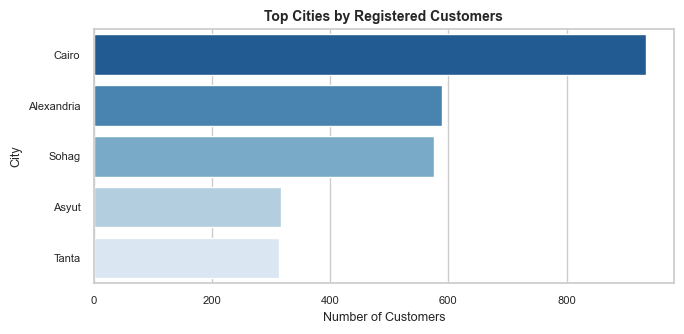

In [13]:
df_customers = sheets_dict['Clean_online_shopping_db_custom']

plt.figure(figsize=(7, 3.5))
top_cities = df_customers['City'].value_counts().head(5)

sns.barplot(x=top_cities.values, y=top_cities.index, palette='Blues_r')
plt.title('Top Cities by Registered Customers', fontweight='bold', fontsize=10)
plt.xlabel('Number of Customers', fontsize=9)
plt.ylabel('City', fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

###  Key Insight & Recommendation

* Visual Insight: Cairo is the primary market hub, followed by Alexandria and strong presence in Upper Egypt (Sohag, Asyut).
* Strategic Recommendation: Focus marketing campaigns and establish fulfillment hubs in Cairo and Alexandria, while expanding regional shipping routes to serve growing demand in Upper Egypt.

#### Visualization 2: Payment Method Preferences (Pie Chart)


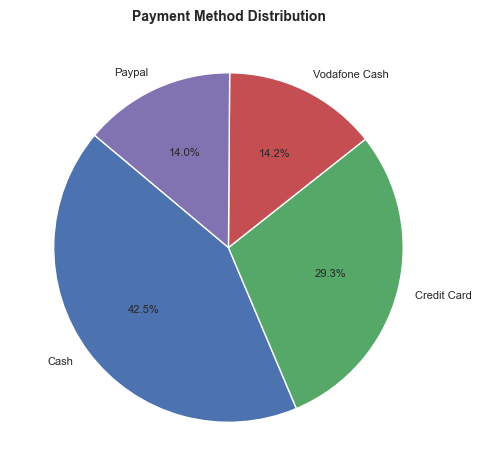

In [14]:
df_orders = sheets_dict['online_shopping_db_orders']
payment_counts = df_orders['Payment_Method'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=['#4C72B0', '#55A868', '#C44E52', '#8172B1'],
        textprops={'fontsize': 8})

plt.title('Payment Method Distribution', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

###  Key Insight & Recommendation

* Visual Insight: Cash dominates the payment preferences at 42.5%, followed by Credit Cards (29.3%), while digital wallets account for the remaining share.
* Strategic Recommendation: Offer checkout incentives and discounts for digital payment methods (Cards & Wallets) to reduce cash-handling risks and operational overhead.

#### Visualization 3: Salary Distribution across Job Titles (Box Plot)


C:\Users\Dell\AppData\Local\Temp\temp\ipykernel_24084\262568768.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_employees, x='Job_Title', y='Salary', palette='Set2')


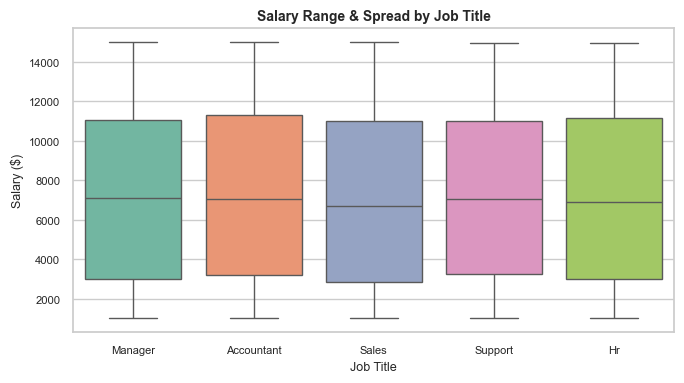

In [ ]:
df_employees = sheets_dict['online_shopping_db_employees']

plt.figure(figsize=(7, 4))
sns.boxplot(data=df_employees, x='Job_Title', y='Salary', palette='Set2')
plt.title('Salary Range & Spread by Job Title', fontweight='bold', fontsize=10)
plt.xlabel('Job Title', fontsize=9)
plt.ylabel('Salary ($)', fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

###  Key Insight & Recommendation

* Visual Insight: Salary distribution shows consistent spread and median across all job titles without any extreme outliers.
* Strategic Recommendation: Maintain current compensation bands while establishing merit-based performance bonuses for highly experienced roles.

#### Visualization 4: Product Price Distribution

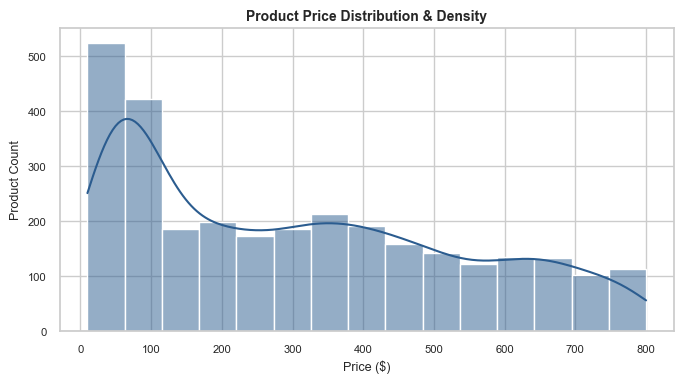

In [19]:
df_products = sheets_dict['Clean_online_shopping_db_produc']

plt.figure(figsize=(7, 4))
sns.histplot(df_products['Price'], kde=True, color='#2b5c8f', bins=15)
plt.title('Product Price Distribution & Density', fontweight='bold', fontsize=10)
plt.xlabel('Price ($)', fontsize=9)
plt.ylabel('Product Count', fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

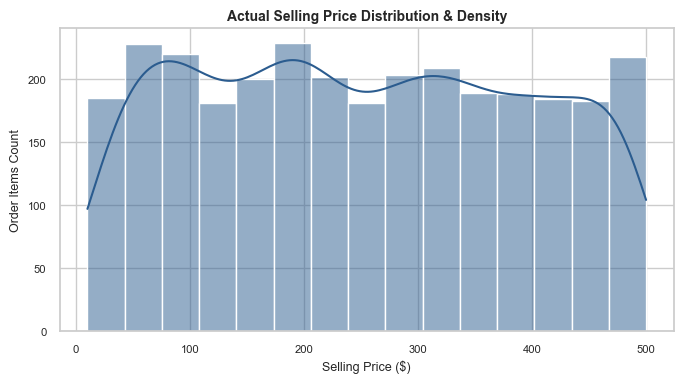

In [20]:
# Visualization 4: Actual Selling Price Distribution (Histogram + KDE)
df_order_items = sheets_dict['online_shopping_db_order_items']

plt.figure(figsize=(7, 4))
sns.histplot(df_order_items['Selling_Price'], kde=True, color='#2b5c8f', bins=15)
plt.title('Actual Selling Price Distribution & Density', fontweight='bold', fontsize=10)
plt.xlabel('Selling Price ($)', fontsize=9)
plt.ylabel('Order Items Count', fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

###  Comparative Insight & Recommendation

* Visual Insight: Comparing catalog prices with actual sales reveals a key pattern: while inventory is heavily weighted toward budget items (< $200), actual purchases are evenly distributed across all price tiers up to $500.
* Strategic Recommendation: Avoid over-stocking only cheap items. Maintain a balanced inventory mix, as customer purchasing power supports mid and high-ticket products equally well.

#### Visualization 5: Order Quantity vs. Total Revenue 


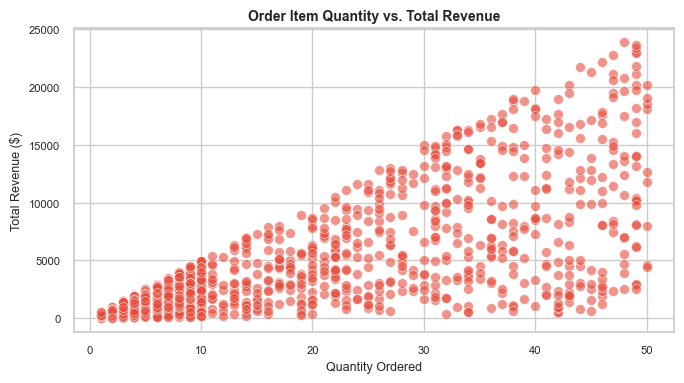

In [21]:
df_order_items = sheets_dict['online_shopping_db_order_items']
df_order_items['Total_Item_Revenue'] = df_order_items['Quantity'] * df_order_items['Selling_Price']

plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df_order_items, 
    x='Quantity', 
    y='Total_Item_Revenue', 
    color='#e74c3c', 
    alpha=0.6, 
    s=50
)

plt.title('Order Item Quantity vs. Total Revenue', fontweight='bold', fontsize=10)
plt.xlabel('Quantity Ordered', fontsize=9)
plt.ylabel('Total Revenue ($)', fontsize=9)
plt.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

###  Key Insight & Recommendation

* Visual Insight: Strong positive correlation between order quantity and total revenue, with higher quantity orders generating substantially greater revenue up to $25,000.
* Strategic Recommendation: Implement tiered bulk discounts and wholesale incentives to encourage customers to place higher-quantity orders.